# PFM-xLSTM-MIL (Final Structured Notebook)

This notebook is a clean, production-style pipeline for training PFM-xLSTM-MIL on real CAMELYON16 features.

## 1) Environment and Imports

In [1]:
!pip -q install timm h5py scikit-learn matplotlib hilbertsfc huggingface_hub pandas
# Pin xlstm from upstream; newer commits may need updates to resolve_mlstm_block_factory.
# Example: pip install "git+https://github.com/NX-AI/xlstm.git@<commit_hash>"
!pip -q install git+https://github.com/NX-AI/xlstm.git
!test -d /content/vision-lstm || git clone -q https://github.com/NX-AI/vision-lstm /content/vision-lstm

import os
import sys
import re
import math
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

for p in ["/content/vision-lstm", "/content/vision-lstm/src", "/content/xlstm"]:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.4/357.4 kB 28.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 140.3 MB/s eta 0:00:00
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2) Download Dataset from Hugging Face

If dataset is gated, make sure your `HF_TOKEN` is stored in Colab Secrets and accessible.
You can also set the **`HF_TOKEN` environment variable** (or use `huggingface-cli login`) if not using Colab `userdata`.


In [2]:
from huggingface_hub import snapshot_download

HF_TOKEN = None
try:
    from google.colab import userdata

    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    pass
if HF_TOKEN is None:
    HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN is None:
    print(
        "HF_TOKEN not set: gated datasets may fail. "
        "Add Colab Secret HF_TOKEN, set os.environ['HF_TOKEN'], or use `huggingface-cli login`."
    )

HF_REPO = "kaczmarj/camelyon16-uni"
DATA_ROOT = Path("/content/camelyon16_uni_data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

local_repo = Path(
    snapshot_download(
        repo_id=HF_REPO,
        repo_type="dataset",
        token=HF_TOKEN,
        local_dir=str(DATA_ROOT),
    )
)

EMBED_DIR = local_repo / "embeddings"
PATCH_DIR = local_repo / "patches"
PROCESS_CSV = PATCH_DIR / "process_list_autogen.csv"

print("Repo root:", local_repo)
print("Embeddings dir:", EMBED_DIR)
print("Patches dir:", PATCH_DIR)
print("Manifest:", PROCESS_CSV)
print("#pt:", len(list(EMBED_DIR.glob("*.pt"))))
print("#h5:", len(list(PATCH_DIR.rglob("*.h5"))))

_h = next(iter(PATCH_DIR.rglob("*.h5")), None)
if _h is not None:
    with h5py.File(_h, "r") as _f:
        print("Example h5:", _h.name, "| keys:", list(_f.keys()))


Fetching ... files: 0it [00:00, ?it/s]

Repo root: /content/camelyon16_uni_data
Embeddings dir: /content/camelyon16_uni_data/embeddings
Patches dir: /content/camelyon16_uni_data/patches
Manifest: /content/camelyon16_uni_data/patches/process_list_autogen.csv
#pt: 399
#h5: 399
Example h5: test_095.h5 | keys: ['coords']


## 3) Real Dataset Loader with Hilbert Sorting

This loader:
- pairs `.pt` features and `.h5` coords robustly,
- infers labels from slide names (`normal`/`tumor`),
- applies Hilbert sorting,
- keeps full variable-length bags (no truncation/padding), then applies Hilbert sorting.

In [3]:
def _norm_id(s):
    s = str(s).strip().lower()
    s = Path(s).stem
    return re.sub(r"[^a-z0-9]+", "", s)


def infer_label_from_slide_id(slide_id_stem):
    s = slide_id_stem.lower()
    if "tumor" in s:
        return 1
    if "normal" in s:
        return 0
    return None


def _xy2d(n_side, x, y):
    d = 0
    s = n_side // 2
    while s > 0:
        rx = 1 if (x & s) else 0
        ry = 1 if (y & s) else 0
        d += s * s * ((3 * rx) ^ ry)
        if ry == 0:
            if rx == 1:
                x = n_side - 1 - x
                y = n_side - 1 - y
            x, y = y, x
        s //= 2
    return d


def hilbert_indices(coords_np):
    try:
        import hilbertsfc

        mx = int(coords_np.max()) if coords_np.size else 0
        p = max(1, int(math.ceil(math.log2(mx + 1))))
        if hasattr(hilbertsfc, "hilbert_index"):
            return np.array([hilbertsfc.hilbert_index(int(x), int(y), p=p) for x, y in coords_np], dtype=np.int64)
        if hasattr(hilbertsfc, "encode"):
            try:
                return np.array(hilbertsfc.encode(coords_np.astype(np.int64)), dtype=np.int64)
            except Exception:
                return np.array(hilbertsfc.encode(coords_np.astype(np.int64).T), dtype=np.int64)
    except Exception:
        pass
    mx = int(coords_np.max()) if coords_np.size else 0
    p = max(1, int(math.ceil(math.log2(mx + 1))))
    n_side = 1 << p
    return np.array([_xy2d(n_side, int(x), int(y)) for x, y in coords_np.astype(np.int64)], dtype=np.int64)


class WSIFeatureDataset(Dataset):
    def __init__(self, embed_dir, patch_dir, process_csv):
        self.embed_dir = Path(embed_dir)
        self.patch_dir = Path(patch_dir)

        df = pd.read_csv(process_csv)
        if "slide_id" not in df.columns:
            raise ValueError(f"'slide_id' missing. Columns: {list(df.columns)}")

        split_col = next((c for c in ["split", "set", "subset", "partition"] if c in df.columns), None)

        pt_files = sorted(self.embed_dir.glob("*.pt"))
        h5_files = sorted(self.patch_dir.rglob("*.h5"))
        pt_map = {_norm_id(p.stem): p for p in pt_files}
        h5_map = {_norm_id(p.stem): p for p in h5_files}

        self.samples = []
        for _, row in df.iterrows():
            sid_stem = Path(str(row["slide_id"]).strip()).stem
            label = infer_label_from_slide_id(sid_stem)
            if label is None:
                continue

            if split_col is not None and pd.notna(row[split_col]):
                split_name = str(row[split_col]).strip().lower()
            else:
                sid_lower = sid_stem.lower()
                if sid_lower.startswith("test_"):
                    split_name = "test"
                elif sid_lower.startswith(("normal_", "tumor_")):
                    split_name = "train"
                else:
                    split_name = "unknown"

            key = _norm_id(sid_stem)
            pt_path = pt_map.get(key)
            h5_path = h5_map.get(key)
            if pt_path is None or h5_path is None:
                continue
            self.samples.append((sid_stem, pt_path, h5_path, int(label), split_name))

        if len(self.samples) == 0:
            raise RuntimeError("No matched samples found after pairing manifest <-> pt <-> h5")

        # One H5 read per slide builds Hilbert order (and caches raw coords for coord-returning path).
        self._slide_geom_cache = {}

        y = np.array([s[3] for s in self.samples], dtype=np.int64)
        split_counts = pd.Series([s[4] for s in self.samples]).value_counts().to_dict()
        print(f"Loaded {len(self.samples)} slides | normal={(y==0).sum()} tumor={(y==1).sum()}")
        print(f"Split counts: {split_counts}")

    def __len__(self):
        return len(self.samples)

    def indices_for_split(self, split_name):
        target = str(split_name).strip().lower()
        return np.array([i for i, s in enumerate(self.samples) if s[4] == target], dtype=np.int64)

    def _read_coords_h5(self, h5_path, sid=""):
        with h5py.File(h5_path, "r") as f:
            if "coords" in f:
                coords = f["coords"][:]
            else:
                coords = None
                for k in f.keys():
                    arr = f[k][:]
                    if arr.ndim == 2 and arr.shape[1] == 2:
                        coords = arr
                        break
                if coords is None:
                    raise KeyError(f"{sid}: no coordinate dataset (N,2) found")
        return np.asarray(coords, dtype=np.float64)

    def _slide_geom(self, sid, h5_path, n_feats):
        """Return (order, coords_np) with a single H5 coordinate read per slide (cached)."""
        cached = self._slide_geom_cache.get(sid)
        if cached is not None:
            n0, order, coords_np = cached["n"], cached["order"], cached["coords"]
            if int(n_feats) != int(n0):
                raise ValueError(
                    f"{sid}: features length changed ({n_feats} != cached {n0}); possible data mismatch"
                )
            return order, coords_np

        coords_np = self._read_coords_h5(h5_path, sid)
        if coords_np.shape[0] != n_feats:
            raise ValueError(
                f"{sid}: mismatched patch counts feat={n_feats} coord={coords_np.shape[0]}; refusing to silently truncate"
            )
        if n_feats == 0:
            raise RuntimeError(f"{sid}: empty bag")

        order = np.argsort(hilbert_indices(coords_np.astype(np.int64, copy=False)))
        self._slide_geom_cache[sid] = {"n": int(n_feats), "order": order, "coords": coords_np}
        return order, coords_np

    def _load_bag_tensor(self, idx):
        """Raw feats from .pt (not Hilbert-ordered yet)."""
        sid, pt_path, h5_path, label, split_name = self.samples[idx]
        feats = torch.load(pt_path, map_location="cpu")
        if isinstance(feats, dict):
            feats = feats["features"] if "features" in feats else next(iter(feats.values()))
        feats = torch.as_tensor(feats, dtype=torch.float32)
        if feats.ndim != 2:
            raise ValueError(f"{sid}: expected 2D features, got {tuple(feats.shape)}")
        y = torch.tensor([float(label)], dtype=torch.float32)
        return sid, h5_path, feats, y, split_name

    def load_bag_features_only(self, idx):
        """Hilbert-ordered features; one H5 read on first access per slide (for ordering only)."""
        sid, h5_path, feats, y, split_name = self._load_bag_tensor(idx)
        order, _coords = self._slide_geom(sid, h5_path, feats.shape[0])
        feats = feats[torch.from_numpy(order)]
        return {"slide_id": sid, "features": feats, "label": y, "split": split_name}

    def load_bag_with_coords(self, idx):
        """Hilbert-ordered features + patch coords (same single H5 read as features-only path when cached)."""
        sid, h5_path, feats, y, split_name = self._load_bag_tensor(idx)
        order, coords_np = self._slide_geom(sid, h5_path, feats.shape[0])
        ot = torch.from_numpy(order)
        feats = feats[ot]
        coords = torch.from_numpy(coords_np)[ot]
        return {"slide_id": sid, "features": feats, "coords": coords, "label": y, "split": split_name}

    def __getitem__(self, idx):
        return self.load_bag_features_only(idx)


dataset = WSIFeatureDataset(EMBED_DIR, PATCH_DIR, PROCESS_CSV)
FEATURE_DIM = dataset[0]["features"].shape[1]
print("Detected feature dim:", FEATURE_DIM)
ex = dataset[0]
print("Example:", ex["slide_id"], tuple(ex["features"].shape), ex["label"].item())



Loaded 270 slides | normal=159 tumor=111
Split counts: {'train': 270}
Detected feature dim: 1024
Example: normal_001 (2126, 1024) 0.0


## 4) Model Definition (Input Dim from Dataset)

In [4]:
import importlib
import os
import torch.nn.functional as F

# "factory" = try multiple xlstm / vision-lstm import paths (default).
# "simple" = only `xlstm.blocks.mlstm.block` (set XLSTM_BACKEND=simple or assign below).
XLSTM_BACKEND = os.environ.get("XLSTM_BACKEND", "factory").lower()


def _try_set_mlstm_dropout(mlstm_cfg, p=0.1):
    """Apply dropout-related fields when the installed xlstm exposes them (often none)."""
    applied = []
    for name in (
        "dropout",
        "attention_dropout",
        "attn_dropout",
        "proj_dropout",
        "output_dropout",
        "embedding_dropout",
    ):
        if hasattr(mlstm_cfg, name):
            try:
                setattr(mlstm_cfg, name, float(p))
                applied.append(name)
            except Exception:
                pass
    return applied


def _factory_from_config_module(mod, hidden_dim, context_length, backend, num_heads, mlstm_dropout):
    """Build factory(mod.mLSTMBlock, mod.mLSTMBlockConfig, ...). Raises on failure."""
    mblock_cls = getattr(mod, "mLSTMBlock")
    cfg_cls = getattr(mod, "mLSTMBlockConfig", None)
    if cfg_cls is None:
        raise RuntimeError("mLSTMBlockConfig missing on module")

    cfg = cfg_cls()
    if hasattr(cfg, "_num_blocks"):
        cfg._num_blocks = 2
    if hasattr(cfg, "_block_idx"):
        cfg._block_idx = 0
    applied = []
    if hasattr(cfg, "mlstm"):
        cfg.mlstm.embedding_dim = int(hidden_dim)
        cfg.mlstm.context_length = int(context_length)
        cfg.mlstm.num_heads = int(num_heads)
        cfg.mlstm.qkv_proj_blocksize = 4
        cfg.mlstm._num_blocks = getattr(cfg, "_num_blocks", 2)
        cfg.mlstm.backend = backend
        applied = _try_set_mlstm_dropout(cfg.mlstm, mlstm_dropout)
    if hasattr(cfg, "__post_init__"):
        cfg.__post_init__()
    _ = mblock_cls(cfg)

    def factory(dim):
        c = cfg_cls()
        if hasattr(c, "_num_blocks"):
            c._num_blocks = 2
        if hasattr(c, "_block_idx"):
            c._block_idx = 0
        if hasattr(c, "mlstm"):
            c.mlstm.embedding_dim = int(dim)
            c.mlstm.context_length = int(context_length)
            c.mlstm.num_heads = int(num_heads)
            c.mlstm.qkv_proj_blocksize = 4
            c.mlstm._num_blocks = getattr(c, "_num_blocks", 2)
            c.mlstm.backend = backend
            _try_set_mlstm_dropout(c.mlstm, mlstm_dropout)
        if hasattr(c, "__post_init__"):
            c.__post_init__()
        return mblock_cls(c)

    mod_name = getattr(mod, "__name__", str(mod))
    print(
        f"mLSTMBlock resolved: {mod_name} (config constructor, heads={num_heads}, "
        f"mlstm_dropout_attempt={mlstm_dropout}, applied={applied if applied else 'none'})"
    )
    return factory


def resolve_mlstm_block_factory(
    hidden_dim=256,
    context_length=10_000,
    backend="chunkwise",
    num_heads=4,
    mlstm_dropout=0.1,
):
    mode = globals().get("XLSTM_BACKEND", os.environ.get("XLSTM_BACKEND", "factory"))
    mode = str(mode).lower().strip()
    if mode not in ("factory", "simple"):
        raise ValueError('XLSTM_BACKEND must be "factory" or "simple"')

    if mode == "simple":
        try:
            mod = importlib.import_module("xlstm.blocks.mlstm.block")
            return _factory_from_config_module(mod, hidden_dim, context_length, backend, num_heads, mlstm_dropout)
        except Exception as e:
            raise RuntimeError(
                'XLSTM_BACKEND="simple" failed. Install pinned xlstm (see install cell) or switch to factory mode.'
            ) from e

    candidates = [
        ("xlstm.blocks.mlstm.block", "mLSTMBlock", "mLSTMBlockConfig"),
        ("vislstm.modules.xlstm.blocks.mlstm.block", "mLSTMBlock", "mLSTMBlockConfig"),
        ("vision_lstm.vision_lstm2", "mLSTMBlock", "mLSTMBlockConfig"),
    ]
    errors = []
    for mod_name, cls_name, cfg_name in candidates:
        try:
            mod = importlib.import_module(mod_name)
        except Exception as e:
            errors.append((mod_name, "import", repr(e)))
            continue
        if not hasattr(mod, cls_name):
            errors.append((mod_name, "missing_class", cls_name))
            continue
        mblock_cls = getattr(mod, cls_name)
        cfg_cls = getattr(mod, cfg_name, None)

        if cfg_cls is not None:
            try:
                return _factory_from_config_module(mod, hidden_dim, context_length, backend, num_heads, mlstm_dropout)
            except Exception as e:
                errors.append((mod_name, "config_path", repr(e)))

        try:
            _ = mblock_cls(hidden_dim)

            def factory(dim):
                return mblock_cls(dim)

            print(f"mLSTMBlock resolved: {mod_name} (dim constructor; no config dropout)")
            return factory
        except Exception as e:
            errors.append((mod_name, "dim_ctor", repr(e)))

    lines = "\n".join(f"  - {t[0]} [{t[1]}]: {t[2]}" for t in errors)
    raise RuntimeError(
        "resolve_mlstm_block_factory: could not construct mLSTMBlock from any candidate module.\n"
        "Try `pip install git+https://github.com/NX-AI/xlstm.git` (pin a commit if your environment drifts) "
        'or set XLSTM_BACKEND="simple" after verifying `import xlstm.blocks.mlstm.block`.\n'
        f"Attempt log:\n{lines}"
    )


HIDDEN_DIM = 256
NUM_MLSTM_BLOCKS = 2
NUM_HEADS = 4
CLASSIFIER_DROPOUT = 0.5
INPUT_DROPOUT = 0.1
POST_BLOCK_DROPOUT = 0.25
MLP_DIM = 128
MLSTM_CONTEXT_LENGTH = 18_000  # >= MAX_SEQ_LEN / full-bag eval margin

# Uncomment to use only `xlstm.blocks.mlstm.block` (skip multi-path introspection):
# XLSTM_BACKEND = "simple"

mlstm_block_factory = resolve_mlstm_block_factory(
    hidden_dim=HIDDEN_DIM,
    context_length=MLSTM_CONTEXT_LENGTH,
    backend="chunkwise",
    num_heads=NUM_HEADS,
    mlstm_dropout=0.1,
)


class PFMxLSTMMIL(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim=HIDDEN_DIM,
        num_blocks=NUM_MLSTM_BLOCKS,
        mlp_dim=MLP_DIM,
        dropout=CLASSIFIER_DROPOUT,
        input_dropout=INPUT_DROPOUT,
        post_block_dropout=POST_BLOCK_DROPOUT,
    ):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_dropout = nn.Dropout(input_dropout)
        self.post_block_dropout = float(post_block_dropout)
        self.blocks = nn.ModuleList([mlstm_block_factory(hidden_dim) for _ in range(num_blocks)])
        self.bidir_merge = nn.ModuleList(
            [nn.Linear(2 * hidden_dim, hidden_dim) for _ in range(num_blocks)]
        )
        self.pre_head_norm = nn.LayerNorm(hidden_dim)
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, 1),
        )

    def forward(self, x):
        x = self.input_dropout(self.input_proj(x))
        for i, b in enumerate(self.blocks):
            fwd = b(x)
            xr = torch.flip(x, dims=[1])
            bwd = b(xr)
            bwd = torch.flip(bwd, dims=[1])
            x = torch.cat([fwd, bwd], dim=-1)
            x = self.bidir_merge[i](x)
            x = F.dropout(x, p=self.post_block_dropout, training=self.training)
        pooled = self.pre_head_norm(x.mean(dim=1))
        return self.cls_head(pooled)


model = PFMxLSTMMIL(in_dim=FEATURE_DIM).to(device)
print(model.__class__.__name__)
if len(model.blocks) > 0:
    print("First mLSTM block:")
    print(model.blocks[0])



mLSTMBlock resolved: xlstm.blocks.mlstm.block (config constructor, heads=4, mlstm_dropout_attempt=0.1, applied=['dropout'])
PFMxLSTMMIL
First mLSTM block:
mLSTMBlock(
  (xlstm_norm): LayerNorm()
  (xlstm): mLSTMLayer(
    (proj_up): Linear(in_features=256, out_features=1024, bias=False)
    (q_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
    (k_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
    (v_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
    (conv1d): CausalConv1d(
      (conv): Conv1d(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512)
    )
    (conv_act_fn): SiLU()
    (mlstm_cell): mLSTMCell(
      (igate): Linear(in_features=1536, out_features=4, bias=True)
      (fgate): Linear(in_features

## 5) Training (20 Epochs + Class-Imbalance Loss)

In [5]:
import math
from sklearn.model_selection import StratifiedKFold

# Train: Hilbert-ordered random subset (reproducible). Val/metrics: stride. MAX_SEQ_EVAL None = full bag (VRAM).
# When USE_TRAIN_RANDOM_SUBSAMPLE is True: random patch indices are sorted by Hilbert index — order follows the 1D curve but is NOT a contiguous spatial arc on the slide.
MAX_SEQ_LEN = 14_000
MAX_SEQ_EVAL = 14_000
USE_TRAIN_RANDOM_SUBSAMPLE = True
WEIGHT_DECAY = 1e-4
# K_FOLD: 0 = use train/test split above. Set to 5 for stratified K-fold on ALL loaded slides (re-trains each fold).
# When K_FOLD >= 2, skip the single-split "Final ... Metrics" eval cell below; use cv_results_df / fold ROCs here.
K_FOLD = 0
GRAD_CLIP_NORM = 1.0
GRAD_ACCUM_STEPS = 4
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 0.0

CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_model.pt"
RESUME_CHECKPOINT_PATH = CHECKPOINT_DIR / "pfm_xlstm_mil_resume.pt"
SAVE_FULL_RESUME = True

# Best checkpoint: "loss" (default) or "roc_auc" (requires both classes in val set).
SELECTION_METRIC = "loss"
# Optional warm-start: load best model weights from a prior run (optimizer always re-created; not full epoch resume).
# SAVE_FULL_RESUME still writes optimizer state for bookkeeping; true resume-from-epoch is not implemented.
RESUME_WARMSTART_PATH = None  # e.g. CHECKPOINT_DIR / "pfm_xlstm_mil_resume.pt"


def stride_subsample_hilbert(feats, max_len=None):
    """Hilbert-ordered stride subsample; max_len None keeps full sequence."""
    feats = feats if isinstance(feats, torch.Tensor) else torch.as_tensor(feats, dtype=torch.float32)
    feats = feats.contiguous()
    n = int(feats.shape[0])
    if n == 0:
        return feats
    if max_len is None:
        return feats
    if n <= max_len:
        return feats
    idx = torch.linspace(0, n - 1, steps=max_len).round().long()
    return feats[idx]


def hilbert_ordered_random_subset(feats, max_len, generator):
    """Random patch indices, sorted to preserve Hilbert sequence order along the curve."""
    feats = feats if isinstance(feats, torch.Tensor) else torch.as_tensor(feats, dtype=torch.float32)
    feats = feats.contiguous()
    n = int(feats.shape[0])
    if n == 0 or max_len is None or n <= max_len:
        return feats
    perm = torch.randperm(n, generator=generator)[:max_len]
    idx = torch.sort(perm).values.to(device=feats.device, dtype=torch.long)
    return feats[idx]


def prepare_bag_features(feats, max_len=None, training=False, epoch=0, slide_key=0):
    if max_len is None:
        max_len = MAX_SEQ_LEN
    if training and USE_TRAIN_RANDOM_SUBSAMPLE and max_len is not None:
        g = torch.Generator()
        seed = (int(SEED) + int(epoch) * 1_000_003 + int(slide_key) * 9176) & 0x7FFFFFFF
        g.manual_seed(seed)
        return hilbert_ordered_random_subset(feats, max_len, g)
    return stride_subsample_hilbert(feats, max_len)


all_idx = np.arange(len(dataset), dtype=np.int64)
all_labels = np.array([int(dataset[i]["label"].item()) for i in all_idx], dtype=np.int64)

train_idx = dataset.indices_for_split("train")
val_idx = dataset.indices_for_split("test")

if len(train_idx) == 0:
    raise RuntimeError("No training samples detected. Check manifest split labels or slide naming.")

if len(val_idx) == 0:
    # Typical HF layout: all slides are usable for training; create a stratified eval holdout here.
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=all_labels,
    )

print(f"Train slides: {len(train_idx)} | Eval slides: {len(val_idx)}")


def run_fit(model, train_idx, val_idx, max_epochs=None, save_checkpoints=True, weight_decay=None, lr_max=None, selection_metric=None, resume_path=None):
    train_labels = np.array([int(dataset[i]["label"].item()) for i in train_idx], dtype=np.int64)
    num_pos = int((train_labels == 1).sum())
    num_neg = int((train_labels == 0).sum())
    if num_pos == 0:
        raise RuntimeError("No positive training slides found; cannot compute pos_weight.")
    pos_weight = torch.tensor([num_neg / max(1, num_pos)], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    EPOCHS = int(max_epochs) if max_epochs is not None else 20
    LR_MAX = float(lr_max) if lr_max is not None else 5e-5
    LR_WARMUP_START = min(1e-5, LR_MAX * 0.25) if LR_MAX > 0 else 1e-6
    LR_MIN = 1e-6
    warmup_epochs = min(5, EPOCHS)
    wd = float(weight_decay) if weight_decay is not None else WEIGHT_DECAY

    sel = selection_metric if selection_metric is not None else globals().get("SELECTION_METRIC", "loss")
    sel = str(sel).lower().strip()
    if sel not in ("loss", "roc_auc"):
        raise ValueError('selection_metric must be "loss" or "roc_auc"')

    rw = resume_path if resume_path is not None else globals().get("RESUME_WARMSTART_PATH")
    if rw:
        p = Path(rw)
        if p.is_file():
            d = torch.load(p, map_location="cpu")
            sd = d.get("model_state_dict_best") or d.get("model_state_dict")
            if sd is not None:
                model.load_state_dict(sd, strict=True)
                print(f"Warm-started model weights from {p}")

    optimizer = optim.AdamW(model.parameters(), lr=LR_WARMUP_START, weight_decay=wd)

    train_losses, val_losses, lr_hist, gpu_peak_mem_gb = [], [], [], []
    best_primary = float("inf") if sel == "loss" else float("-inf")
    best_val_loss_at_best = float("inf")
    best_roc_at_best = float("nan")
    best_state = None
    best_epoch = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        if epoch <= warmup_epochs:
            lr = LR_WARMUP_START + (LR_MAX - LR_WARMUP_START) * (epoch / max(1, warmup_epochs))
        else:
            t = (epoch - warmup_epochs - 1) / max(1, EPOCHS - warmup_epochs)
            lr = LR_MIN + (LR_MAX - LR_MIN) * 0.5 * (1.0 + math.cos(math.pi * t))
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        model.train()
        epoch_train = 0.0
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        optimizer.zero_grad(set_to_none=True)
        order = np.random.permutation(train_idx)
        n_order = len(order)
        for step_i, idx in enumerate(order):
            bag = dataset[int(idx)]
            feats = prepare_bag_features(bag["features"], training=True, epoch=epoch, slide_key=int(idx))

            x = feats.unsqueeze(0).to(device)
            y = bag["label"].to(device)

            loss = criterion(model(x).squeeze(-1), y)
            (loss / GRAD_ACCUM_STEPS).backward()
            epoch_train += float(loss.item())

            if (step_i + 1) % GRAD_ACCUM_STEPS == 0 or (step_i + 1) == n_order:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

        epoch_train /= len(train_idx)
        train_losses.append(epoch_train)

        model.eval()
        epoch_val = 0.0
        val_true, val_prob = [], []
        with torch.no_grad():
            for idx in val_idx:
                bag = dataset[int(idx)]
                feats = stride_subsample_hilbert(bag["features"], MAX_SEQ_LEN)

                x = feats.unsqueeze(0).to(device)
                y = bag["label"].to(device)
                logits = model(x).squeeze(-1)
                epoch_val += float(criterion(logits, y).item())
                val_true.append(float(y.item()))
                val_prob.append(float(torch.sigmoid(logits).item()))

        epoch_val /= len(val_idx)
        val_losses.append(epoch_val)

        val_true = np.array(val_true, dtype=np.float32)
        val_prob = np.array(val_prob, dtype=np.float32)
        val_pred = (val_prob >= 0.5).astype(np.int64)
        val_acc = float((val_pred == val_true.astype(np.int64)).mean())
        if len(np.unique(val_true)) > 1:
            val_roc_auc = float(roc_auc_score(val_true, val_prob))
            val_pr_auc = float(average_precision_score(val_true, val_prob))
        else:
            val_roc_auc = float("nan")
            val_pr_auc = float("nan")

        lr_now = optimizer.param_groups[0]["lr"]
        lr_hist.append(lr_now)
        peak_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 3) if torch.cuda.is_available() else 0.0
        gpu_peak_mem_gb.append(float(peak_mem))

        improved = False
        if sel == "loss":
            improved = epoch_val < best_primary - EARLY_STOP_MIN_DELTA
            if improved:
                best_primary = epoch_val
                best_val_loss_at_best = epoch_val
                if len(np.unique(val_true)) > 1 and not np.isnan(val_roc_auc):
                    best_roc_at_best = val_roc_auc
        else:
            if len(np.unique(val_true)) > 1 and not np.isnan(val_roc_auc):
                improved = val_roc_auc > best_primary + EARLY_STOP_MIN_DELTA
            if improved:
                best_primary = val_roc_auc
                best_val_loss_at_best = epoch_val
                best_roc_at_best = val_roc_auc

        if improved:
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = int(epoch)
            epochs_no_improve = 0
            if save_checkpoints:
                ck_meta = {
                    "model_state_dict": best_state,
                    "epoch": best_epoch,
                    "best_eval_loss": float(best_val_loss_at_best),
                    "selection_metric": sel,
                    "best_primary": float(best_primary),
                }
                if not np.isnan(best_roc_at_best):
                    ck_meta["best_roc_auc"] = float(best_roc_at_best)
                torch.save(ck_meta, BEST_MODEL_PATH)
                msg = f"eval_loss={best_val_loss_at_best:.4f}"
                if sel == "roc_auc":
                    msg += f" roc_auc={best_primary:.4f}"
                print(f"Saved best model to {BEST_MODEL_PATH} (epoch {best_epoch}, {msg}, criterion={sel})")
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | LR {lr_now:.2e} | Train {epoch_train:.4f} | "
            f"EvalLoss {epoch_val:.4f} | EvalAcc {val_acc:.4f} | EvalROC-AUC {val_roc_auc:.4f} | "
            f"EvalPR-AUC {val_pr_auc:.4f} | PeakGPU {peak_mem:.3f} GB"
        )

        if EARLY_STOP_PATIENCE > 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            mname = "eval loss" if sel == "loss" else "eval ROC-AUC"
            bdisp = best_primary
            print(
                f"Early stopping at epoch {epoch}/{EPOCHS} "
                f"(no {mname} improvement for {EARLY_STOP_PATIENCE} epochs; "
                f"best {mname}={bdisp:.4f})."
            )
            break

    last_model_sd = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model weights (selection_metric={sel}).")

    if SAVE_FULL_RESUME and save_checkpoints:
        torch.save(
            {
                "model_state_dict_last": last_model_sd,
                "model_state_dict_best": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "last_epoch": int(epoch),
                "best_epoch": best_epoch,
                "best_eval_loss": float(best_val_loss_at_best),
                "selection_metric": sel,
                "best_primary": float(best_primary),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "lr_hist": lr_hist,
                "gpu_peak_mem_gb": gpu_peak_mem_gb,
                "train_idx": np.asarray(train_idx, dtype=np.int64),
                "val_idx": np.asarray(val_idx, dtype=np.int64),
                "meta": {
                    "FEATURE_DIM": int(FEATURE_DIM),
                    "SEED": int(SEED),
                    "MAX_SEQ_LEN": int(MAX_SEQ_LEN),
                },
            },
            RESUME_CHECKPOINT_PATH,
        )
        print(f"Saved training resume to {RESUME_CHECKPOINT_PATH}")

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lr_hist": lr_hist,
        "gpu_peak_mem_gb": gpu_peak_mem_gb,
    }
    history["selection_metric"] = sel
    history["best_primary"] = float(best_primary)
    history["best_eval_loss_at_best"] = float(best_val_loss_at_best)
    return model, history, best_val_loss_at_best


cv_histories = []
cv_fold_rocs = []

if K_FOLD >= 2:
    print(f"Running {K_FOLD}-fold stratified CV on {len(all_idx)} slides (ignores single split above).")
    print("NOTE: downstream single-split eval cell should be skipped in CV mode.")
    skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=SEED)
    for fold, (tr, va) in enumerate(skf.split(all_idx, all_labels)):
        print(f"--- Fold {fold + 1}/{K_FOLD} ---")
        mdl = PFMxLSTMMIL(in_dim=FEATURE_DIM).to(device)
        mdl, hist, _bv = run_fit(mdl, all_idx[tr], all_idx[va])
        cv_histories.append(hist)

        val_true, val_prob = [], []
        mdl.eval()
        with torch.no_grad():
            for idx in all_idx[va]:
                bag = dataset[int(idx)]
                feats = stride_subsample_hilbert(bag["features"], MAX_SEQ_LEN)
                x = feats.unsqueeze(0).to(device)
                logits = mdl(x).squeeze(-1)
                val_true.append(float(bag["label"].item()))
                val_prob.append(float(torch.sigmoid(logits).item()))
        val_true = np.array(val_true, dtype=np.float32)
        val_prob = np.array(val_prob, dtype=np.float32)
        roc = float(roc_auc_score(val_true, val_prob)) if len(np.unique(val_true)) > 1 else float("nan")
        cv_fold_rocs.append(roc)
        print(f"Fold {fold + 1} holdout ROC-AUC: {roc:.4f}")

    model = mdl
    min_len = min(len(h["train_losses"]) for h in cv_histories)
    train_losses = np.mean([h["train_losses"][:min_len] for h in cv_histories], axis=0).tolist()
    val_losses = np.mean([h["val_losses"][:min_len] for h in cv_histories], axis=0).tolist()
    lr_hist = np.mean([h["lr_hist"][:min_len] for h in cv_histories], axis=0).tolist()
    gpu_peak_mem_gb = np.mean([h["gpu_peak_mem_gb"][:min_len] for h in cv_histories], axis=0).tolist()

    cv_results_df = pd.DataFrame({"fold": np.arange(1, K_FOLD + 1), "roc_auc": cv_fold_rocs})
    print(cv_results_df)
    print(f"CV mean ROC-AUC: {float(np.nanmean(cv_fold_rocs)):.4f}")
else:
    model, hist, _ = run_fit(model, train_idx, val_idx)
    train_losses = hist["train_losses"]
    val_losses = hist["val_losses"]
    lr_hist = hist["lr_hist"]
    gpu_peak_mem_gb = hist["gpu_peak_mem_gb"]
# LR schedule plot (single-split path; CV mode aggregates losses above)
if K_FOLD < 2 and lr_hist:
    plt.figure(figsize=(7, 2.5))
    plt.plot(np.arange(1, len(lr_hist) + 1), lr_hist, marker=".", linewidth=1.5)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("LR schedule during training")
    plt.grid(alpha=0.25)
    plt.show()


Train slides: 216 | Eval slides: 54
Saved best model to checkpoints/best_model.pt (epoch 1, eval_loss=0.7981)
Epoch 01/20 | LR 1.80e-05 | Train 0.8273 | EvalLoss 0.7981 | EvalAcc 0.5556 | EvalROC-AUC 0.6207 | EvalPR-AUC 0.5227 | PeakGPU 64.389 GB
Saved best model to checkpoints/best_model.pt (epoch 2, eval_loss=0.7548)
Epoch 02/20 | LR 2.60e-05 | Train 0.7680 | EvalLoss 0.7548 | EvalAcc 0.7037 | EvalROC-AUC 0.7244 | EvalPR-AUC 0.5900 | PeakGPU 64.389 GB
Saved best model to checkpoints/best_model.pt (epoch 3, eval_loss=0.7095)
Epoch 03/20 | LR 3.40e-05 | Train 0.7329 | EvalLoss 0.7095 | EvalAcc 0.6481 | EvalROC-AUC 0.7358 | EvalPR-AUC 0.6996 | PeakGPU 64.389 GB
Saved best model to checkpoints/best_model.pt (epoch 4, eval_loss=0.6234)
Epoch 04/20 | LR 4.20e-05 | Train 0.7173 | EvalLoss 0.6234 | EvalAcc 0.7778 | EvalROC-AUC 0.8182 | EvalPR-AUC 0.7219 | PeakGPU 64.389 GB
Epoch 05/20 | LR 5.00e-05 | Train 0.6319 | EvalLoss 0.6383 | EvalAcc 0.7222 | EvalROC-AUC 0.8224 | EvalPR-AUC 0.7130 | P

## 6) Evaluation and Plots (ROC + PR + Memory + Loss)

In [6]:
from sklearn.metrics import confusion_matrix


def evaluate_model(model, dataset_obj, indices, max_len=None):
    if max_len is None:
        if "MAX_SEQ_EVAL" in globals():
            max_len = globals()["MAX_SEQ_EVAL"]
        else:
            max_len = globals().get("MAX_SEQ_LEN", 14_000)
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for idx in indices:
            bag = dataset_obj[int(idx)]
            feats = stride_subsample_hilbert(bag["features"], max_len)

            x = feats.unsqueeze(0).to(device)
            y = int(bag["label"].item())
            logit = model(x).squeeze().item()
            y_true.append(y)
            y_prob.append(1.0 / (1.0 + math.exp(-logit)))

    y_true = np.array(y_true, dtype=np.int64)
    y_prob = np.array(y_prob, dtype=np.float64)
    y_pred = (y_prob >= 0.5).astype(np.int64)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "avg_precision": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }
    return metrics, y_true, y_prob


# Run evaluation
metrics, y_true, y_prob = evaluate_model(model, dataset, val_idx)

eval_split_name = "test" if len(dataset.indices_for_split("test")) > 0 else "validation"
print(f"Final {eval_split_name.title()} Metrics")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

y_pred = (y_prob >= 0.5).astype(np.int64)
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix [[TN, FP],[FN, TP]] (rows=true, cols=pred):\n", cm)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
axes[0].set_title("Confusion matrix")
for (j, i), val in np.ndenumerate(cm):
    axes[0].text(i, j, int(val), ha="center", va="center", color="black")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

for cls in np.unique(y_true):
    axes[1].hist(y_prob[y_true == cls], bins=30, alpha=0.55, label=f"true={int(cls)}")
axes[1].set_title("Predicted probability by true class")
axes[1].set_xlabel("P(malignant)")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


Final Validation Metrics
accuracy: 0.7778
precision: 0.6923
recall: 0.8182
roc_auc: 0.8182
avg_precision: 0.7219


## Baselines: ABMIL, TransMIL, MambaMIL (AUC + memory)

Same **Hilbert-ordered** patch features, **`train_idx` / `val_idx`**, subsampling (`prepare_bag_features` / `stride_subsample_hilbert`), and **`run_fit`** training as the main model (checkpoints disabled so `best_model.pt` is not overwritten). Set **`RUN_BASELINES = False`** to skip. Reports **ROC-AUC** / PR-AUC (`evaluate_model`) and approximate **peak GPU GB** over a few validation forward passes at **`MAX_SEQ_LEN`**.

| Model | Notebook implementation | Upstream reference |
|-------|-------------------------|-------------------|
| **ABMIL** | Gated attention MIL on patch embeddings (BCE head) | [AttentionDeepMIL](https://github.com/AMLab-Amsterdam/AttentionDeepMIL) (Ilse et al., gated attention) |
| **TransMIL** | Nystrom attention + PPEG + cls token (ported from official `TransMIL.py`; `pip install nystrom-attention`) | [TransMIL](https://github.com/szc19990412/TransMIL) |
| **MambaMIL** | Optional: if **`MAMBAMIL_REPO`** exists (e.g. clone [MambaMIL](https://github.com/isyangshu/MambaMIL) and `pip install` the bundled `mamba` package per their README), the baseline loop trains `models.MambaMIL` with a binary logit wrapper. Otherwise this row is skipped (Mamba needs CUDA build steps outside a plain `pip`). |

Set **`MAMBAMIL_REPO`** in the code cell to your clone path (default checks `/content/MambaMIL` and `./MambaMIL`).
**Memory note:** baseline Transformer-style paths may use **Flash or mem-efficient SDP** on recent PyTorch; reported peak GPU memory is a runtime snapshot, not a proof of quadratic scaling. See §7 for SDP toggles.


In [7]:
import os
import subprocess
import sys

try:
    from nystrom_attention import NystromAttention
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "-q", "install", "nystrom-attention"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    from nystrom_attention import NystromAttention


class GatedAttentionMIL(nn.Module):
    """Gated attention MIL (ABMIL-style pooling on instance features).

    Same spirit as GatedAttention in AttentionDeepMIL (Ilse et al.),
    applied here to precomputed patch embeddings (no CNN).
    """

    def __init__(self, in_dim, attn_dim=128):
        super().__init__()
        self.attention_V = nn.Sequential(nn.Linear(in_dim, attn_dim), nn.Tanh())
        self.attention_U = nn.Sequential(nn.Linear(in_dim, attn_dim), nn.Sigmoid())
        self.attention_w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Linear(in_dim, 1)

    def forward(self, x):
        A = self.attention_w(self.attention_V(x) * self.attention_U(x))
        A = torch.softmax(A, dim=1)
        M = torch.sum(A * x, dim=1)
        return self.classifier(M)


class TransMILShao(nn.Module):
    """TransMIL (Nystrom + PPEG + cls token) from Shao et al., adapted for arbitrary feature dim.

    Ported from https://github.com/szc19990412/TransMIL/blob/main/models/TransMIL.py
    """

    class _TransLayer(nn.Module):
        def __init__(self, dim=512, norm_layer=nn.LayerNorm):
            super().__init__()
            self.norm = norm_layer(dim)
            self.attn = NystromAttention(
                dim=dim,
                dim_head=dim // 8,
                heads=8,
                num_landmarks=dim // 2,
                pinv_iterations=6,
                residual=True,
                dropout=0.1,
            )

        def forward(self, x):
            return x + self.attn(self.norm(x))

    class _PPEG(nn.Module):
        def __init__(self, dim=512):
            super().__init__()
            self.proj = nn.Conv2d(dim, dim, 7, 1, 7 // 2, groups=dim)
            self.proj1 = nn.Conv2d(dim, dim, 5, 1, 5 // 2, groups=dim)
            self.proj2 = nn.Conv2d(dim, dim, 3, 1, 3 // 2, groups=dim)

        def forward(self, x, H, W):
            B, _, C = x.shape
            cls_token, feat_token = x[:, 0], x[:, 1:]
            cnn_feat = feat_token.transpose(1, 2).view(B, C, H, W)
            x = self.proj(cnn_feat) + cnn_feat + self.proj1(cnn_feat) + self.proj2(cnn_feat)
            x = x.flatten(2).transpose(1, 2)
            x = torch.cat((cls_token.unsqueeze(1), x), dim=1)
            return x

    def __init__(self, in_dim, dim=512):
        super().__init__()
        self.dim = dim
        self.pos_layer = self._PPEG(dim=dim)
        self._fc1 = nn.Sequential(nn.Linear(in_dim, dim), nn.ReLU())
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.layer1 = self._TransLayer(dim=dim)
        self.layer2 = self._TransLayer(dim=dim)
        self.norm = nn.LayerNorm(dim)
        self._fc2 = nn.Linear(dim, 1)

    def forward(self, x):
        h = self._fc1(x.float())
        H = int(h.shape[1])
        _H, _W = int(np.ceil(np.sqrt(H))), int(np.ceil(np.sqrt(H)))
        add_length = _H * _W - H
        h = torch.cat([h, h[:, :add_length, :]], dim=1)
        B = h.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1).to(h.device)
        h = torch.cat((cls_tokens, h), dim=1)
        h = self.layer1(h)
        h = self.pos_layer(h, _H, _W)
        h = self.layer2(h)
        h = self.norm(h)[:, 0]
        return self._fc2(h).unsqueeze(-1)


_MAMBAMIL_LAST_ERR = [None]


def _try_load_mambamil():
    """Return True if models.MambaMIL can be imported from a local clone."""
    envp = os.environ.get("MAMBAMIL_REPO", "").strip()
    roots = []
    if envp:
        roots.append(Path(envp))
    roots.extend([Path("/content/MambaMIL"), Path("MambaMIL"), Path.cwd() / "MambaMIL"])
    for r in roots:
        if not r.exists():
            continue
        p = str(r.resolve())
        inserted = p not in sys.path
        if inserted:
            sys.path.insert(0, p)
        try:
            import importlib

            importlib.invalidate_caches()
            from models.MambaMIL import MambaMIL  # noqa: F401

            return True
        except Exception as e:
            _MAMBAMIL_LAST_ERR[0] = f"{type(e).__name__}: {e}"
            if inserted and sys.path and sys.path[0] == p:
                sys.path.pop(0)
    return False


MAMBAMIL_AVAILABLE = _try_load_mambamil()


class MambaMILBinary(nn.Module):
    """Wraps MambaMIL 2-class logits -> single BCE logit (log p/(1-p)).

    https://github.com/isyangshu/MambaMIL/blob/main/models/MambaMIL.py
    """

    def __init__(self, in_dim, layer=2, rate=10, mamba_type="SRMamba"):
        super().__init__()
        from models.MambaMIL import MambaMIL

        self.inner = MambaMIL(
            in_dim,
            n_classes=2,
            dropout=0.25,
            act="relu",
            survival=False,
            layer=layer,
            rate=rate,
            type=mamba_type,
        )

    def forward(self, x):
        logits, *_ = self.inner(x.float())
        z = logits[:, 1] - logits[:, 0]
        return z.unsqueeze(-1)


RUN_BASELINES = False


def baseline_peak_gpu_gb(mil_model, val_indices, max_samples=12):
    mil_model.eval()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)
    with torch.no_grad():
        for idx in val_indices[:max_samples]:
            bag = dataset[int(idx)]
            feats = stride_subsample_hilbert(bag["features"], MAX_SEQ_LEN)
            x = feats.unsqueeze(0).to(device)
            _ = mil_model(x)
    if torch.cuda.is_available():
        torch.cuda.synchronize(device)
        return float(torch.cuda.max_memory_allocated(device) / (1024**3))
    return 0.0


if RUN_BASELINES:
    rows = []
    specs = [
        ("ABMIL", lambda: GatedAttentionMIL(FEATURE_DIM).to(device)),
        ("TransMIL", lambda: TransMILShao(FEATURE_DIM).to(device)),
    ]
    if MAMBAMIL_AVAILABLE:
        specs.append(("MambaMIL", lambda: MambaMILBinary(FEATURE_DIM).to(device)))
    else:
        print("MambaMIL skipped:", _MAMBAMIL_LAST_ERR[0] or "no MambaMIL clone in candidate paths")

    for name, ctor in specs:
        m = ctor()
        run_fit(m, train_idx, val_idx, save_checkpoints=False)
        metrics, _, _ = evaluate_model(m, dataset, val_idx)
        peak_gb = baseline_peak_gpu_gb(m, val_idx)
        rows.append(
            {
                "model": name,
                "roc_auc": metrics["roc_auc"],
                "avg_precision": metrics["avg_precision"],
                "peak_gpu_gb": peak_gb,
            }
        )
        print(
            f"{name} | ROC-AUC {metrics['roc_auc']:.4f} | PR-AUC {metrics['avg_precision']:.4f} | peak GPU ~{peak_gb:.3f} GB"
        )
    baseline_compare_df = pd.DataFrame(rows)
    print(baseline_compare_df.to_string(index=False))
else:
    baseline_compare_df = None



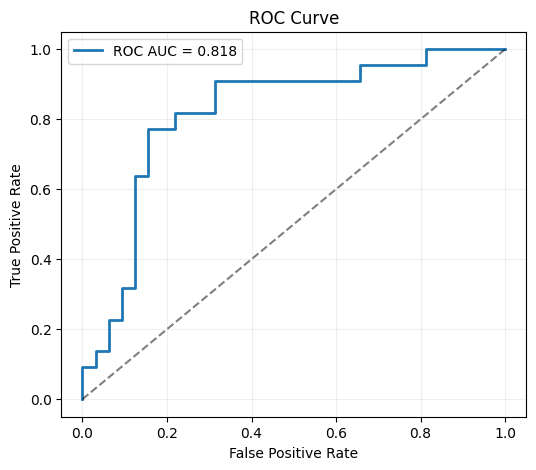

In [8]:
plt.figure(figsize=(6, 5))

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {metrics['roc_auc']:.3f}")
else:
    plt.plot([0, 1], [0, 1], "k--", label="Insufficient class diversity")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

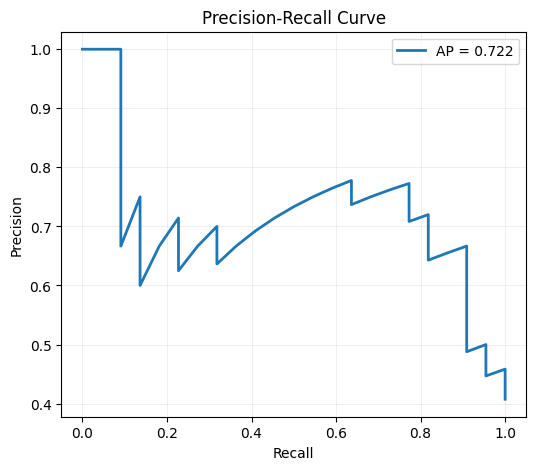

In [9]:
plt.figure(figsize=(6, 5))

if len(np.unique(y_true)) > 1:
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(rec, prec, linewidth=2, label=f"AP = {metrics['avg_precision']:.3f}")
else:
    plt.plot([0, 1], [np.mean(y_true), np.mean(y_true)], "k--",
             label="Insufficient class diversity")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

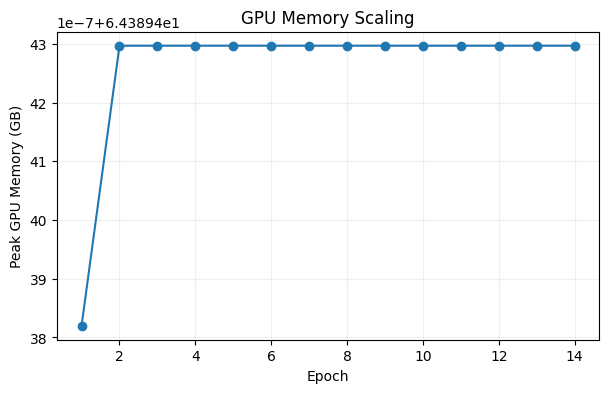

In [10]:
epochs_axis = np.arange(1, len(gpu_peak_mem_gb) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, gpu_peak_mem_gb, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Peak GPU Memory (GB)")
plt.title("GPU Memory Scaling")
plt.grid(alpha=0.2)
plt.show()

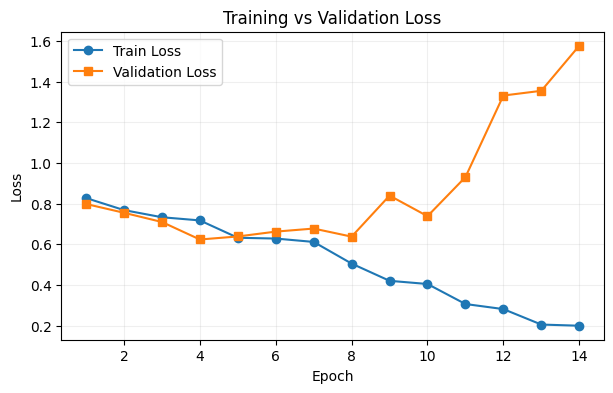

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(epochs_axis, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_axis, val_losses, marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Patch saliency (input gradients)

The demo below computes gradients of the slide-level logit with respect to **patch embedding vectors** (after the linear input projection path). That is a **feature-space sensitivity** map: it shows which embeddings move the decision, not a heatmap over raw WSI pixels. A true WSI overlay would need patch-to-pixel mapping or gradients w.r.t. image data (future extension).


Saliency demo | slide=tumor_075 | patches=4823 | logit=1.4516 | label=1


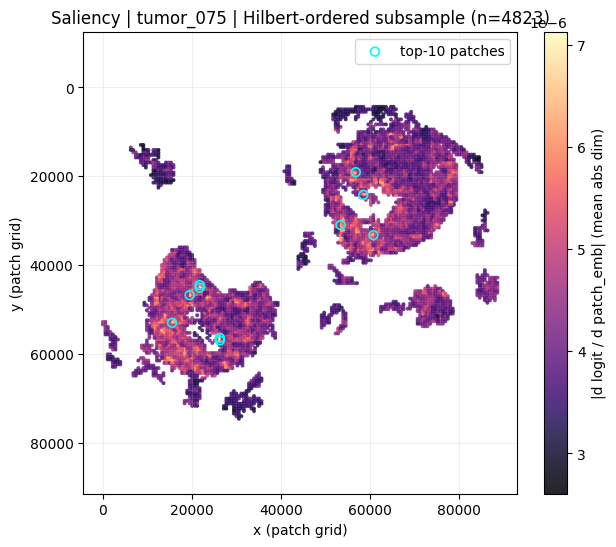

In [12]:
if "MAX_SEQ_LEN" not in globals():
    MAX_SEQ_LEN = 14_000


def subsample_bag_feats_coords(feats, coords, max_len):
    """Match deterministic eval subsampling on both tensors."""
    n = int(feats.shape[0])
    if coords is not None and int(coords.shape[0]) != n:
        raise ValueError("feats/coords length mismatch in subsample_bag_feats_coords")
    if n <= max_len:
        return feats, coords
    idx = torch.linspace(0, n - 1, steps=max_len).round().long()
    if coords is None:
        return feats[idx], None
    return feats[idx], coords[idx]


def patch_input_grad_saliency(model, feats, device, max_len=None):
    """Gradient of scalar logit w.r.t. each patch embedding (input-space saliency)."""
    if max_len is not None:
        feats = subsample_bag_feats_coords(feats, None, max_len)[0]
    model.eval()
    x = feats.unsqueeze(0).to(device).detach().clone().requires_grad_(True)
    logit = model(x).squeeze()
    if logit.ndim != 0:
        logit = logit.reshape(())
    model.zero_grad(set_to_none=True)
    logit.backward()
    g = x.grad.detach()[0]
    importance = g.abs().mean(dim=1).cpu().numpy()
    return importance, float(logit.item())


def plot_slide_saliency_scatter(
    coords_xy,
    importance,
    title="",
    max_points=5000,
    top_k_mark=10,
    s=8,
    cmap="magma",
):
    coords_xy = np.asarray(coords_xy, dtype=np.float64)
    imp = np.asarray(importance, dtype=np.float64)
    if coords_xy.shape[0] != imp.shape[0]:
        raise ValueError(f"coords {coords_xy.shape[0]} vs importance {imp.shape[0]}")

    rng = np.random.default_rng(SEED)
    n = coords_xy.shape[0]
    if n > max_points:
        sub = rng.choice(n, size=max_points, replace=False)
        cx, cy, z = coords_xy[sub, 0], coords_xy[sub, 1], imp[sub]
    else:
        cx, cy, z = coords_xy[:, 0], coords_xy[:, 1], imp

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(cx, cy, c=z, s=s, cmap=cmap, linewidths=0, alpha=0.85)
    plt.colorbar(sc, label="|d logit / d patch_emb| (mean abs dim)")
    if top_k_mark and n >= top_k_mark:
        top = np.argsort(-imp)[:top_k_mark]
        plt.scatter(
            coords_xy[top, 0],
            coords_xy[top, 1],
            s=40,
            facecolors="none",
            edgecolors="cyan",
            linewidths=1.2,
            label=f"top-{top_k_mark} patches",
        )
        plt.legend(loc="best")
    plt.gca().invert_yaxis()
    plt.xlabel("x (patch grid)")
    plt.ylabel("y (patch grid)")
    plt.title(title or "Patch saliency (input gradients)")
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.show()


# --- Demo on one eval slide (change DEMO_IDX to explore) ---
DEMO_IDX = int(val_idx[0]) if "val_idx" in globals() and len(val_idx) > 0 else 0
bag_demo = dataset.load_bag_with_coords(DEMO_IDX)
feats_d, coords_d = subsample_bag_feats_coords(bag_demo["features"], bag_demo["coords"], MAX_SEQ_LEN)
imp, logit0 = patch_input_grad_saliency(model, feats_d, device, max_len=None)
print(
    f"Saliency demo | slide={bag_demo['slide_id']} | patches={len(imp)} | logit={logit0:.4f} | label={bag_demo['label'].item():.0f}"
)
plot_slide_saliency_scatter(
    coords_d.numpy(),
    imp,
    title=f"Saliency | {bag_demo['slide_id']} | Hilbert-ordered subsample (n={len(imp)})",
    max_points=6000,
    top_k_mark=10,
)



## 7) Sequence-length memory scaling (PFM vs Transformer reference)

Peak GPU memory vs patch count for **(1)** your **PFM-xLSTM-MIL** model and **(2)** a small **`nn.TransformerEncoder`** bag classifier on the same synthetic bags.

**Important:** On recent PyTorch + capable GPUs, `nn.TransformerEncoder` often uses **Flash attention** and/or **memory-efficient scaled dot-product attention (SDP)**. Peak memory then scales **sublinearly** with sequence length in practice; this benchmark is a **runtime** comparison, not a proof of asymptotic \(O(N^2)\) memory.

The code below can plot **two** Transformer curves: **SDP defaults** vs **Flash + mem-efficient SDP disabled** (math SDP path), to separate “what PyTorch does by default” from a more classical attention path. After the benchmark, SDP flags are restored so later training is unchanged.

Warmup forwards + `reset_peak_memory_stats` are used before each measured forward. `torch.__version__` and active SDP flags are printed per curve.

If the Transformer run hits **OOM** at long lengths, that point is skipped (`nan`) so the PFM curve can still complete. Adjust **`SEQ_BENCH`** if needed.


[PFM-xLSTM-MIL] N=  1000 | Peak GPU Mem=0.808 GB
[PFM-xLSTM-MIL] N=  2000 | Peak GPU Mem=1.248 GB
[PFM-xLSTM-MIL] N=  4000 | Peak GPU Mem=2.939 GB
[PFM-xLSTM-MIL] N=  6000 | Peak GPU Mem=5.717 GB
[PFM-xLSTM-MIL] N=  8000 | Peak GPU Mem=9.563 GB
[PFM-xLSTM-MIL] N= 12000 | Peak GPU Mem=20.514 GB
[PFM-xLSTM-MIL] N= 14000 | Peak GPU Mem=27.603 GB
[PFM-xLSTM-MIL] N= 16000 | Peak GPU Mem=35.775 GB
[Transformer (full self-attn)] N=  1000 | Peak GPU Mem=0.659 GB
[Transformer (full self-attn)] N=  2000 | Peak GPU Mem=0.675 GB
[Transformer (full self-attn)] N=  4000 | Peak GPU Mem=0.705 GB
[Transformer (full self-attn)] N=  6000 | Peak GPU Mem=0.736 GB
[Transformer (full self-attn)] N=  8000 | Peak GPU Mem=0.766 GB
[Transformer (full self-attn)] N= 12000 | Peak GPU Mem=0.827 GB
[Transformer (full self-attn)] N= 14000 | Peak GPU Mem=0.857 GB
[Transformer (full self-attn)] N= 16000 | Peak GPU Mem=0.888 GB


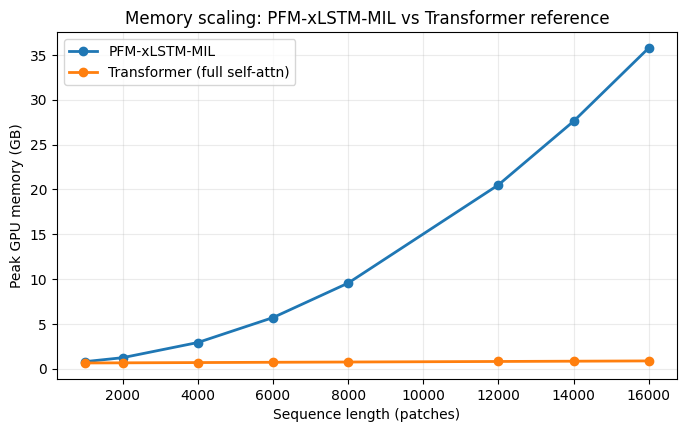

[PFM-xLSTM-MIL] linear fit: mem_gb ≈ 0.002312 * N + -5.1824 | R²=0.9508
[Transformer (full self-attn)] linear fit: mem_gb ≈ 0.000015 * N + 0.6439 | R²=1.0000


model,PFM-xLSTM-MIL,Transformer (full self-attn)
seq_len,,
1000,0.807755,0.658757
2000,1.248344,0.674620
4000,2.939169,0.704533
6000,5.716862,0.735995
8000,9.563034,0.765568
12000,20.513973,0.826603
14000,27.602997,0.857121
16000,35.774772,0.887639


In [13]:
from contextlib import contextmanager


def _log_sdp_flags(note=""):
    if not torch.cuda.is_available():
        print(f"[SDP] CUDA unavailable {note}")
        return
    bits = [f"torch={torch.__version__}"]
    if hasattr(torch.backends.cuda, "is_flash_sdp_enabled"):
        bits.append(f"flash_sdp={torch.backends.cuda.is_flash_sdp_enabled()}")
    if hasattr(torch.backends.cuda, "is_mem_efficient_sdp_enabled"):
        bits.append(f"mem_efficient_sdp={torch.backends.cuda.is_mem_efficient_sdp_enabled()}")
    if hasattr(torch.backends.cuda, "is_math_sdp_enabled"):
        bits.append(f"math_sdp={torch.backends.cuda.is_math_sdp_enabled()}")
    print("[SDP]", note, "|", " ".join(bits))


@contextmanager
def _sdp_benchmark_context(force_classic_attention: bool):
    """When True, turn off Flash and mem-efficient SDP so scaled-dot-product attention uses the math path (closer to full attention memory; still implementation-dependent)."""
    if not torch.cuda.is_available():
        yield
        return
    saved = {}
    try:
        if hasattr(torch.backends.cuda, "enable_flash_sdp"):
            saved["flash"] = torch.backends.cuda.is_flash_sdp_enabled()
            torch.backends.cuda.enable_flash_sdp(not force_classic_attention)
        if hasattr(torch.backends.cuda, "enable_mem_efficient_sdp"):
            saved["mem"] = torch.backends.cuda.is_mem_efficient_sdp_enabled()
            torch.backends.cuda.enable_mem_efficient_sdp(not force_classic_attention)
        if force_classic_attention and hasattr(torch.backends.cuda, "enable_math_sdp"):
            saved["math"] = torch.backends.cuda.is_math_sdp_enabled()
            torch.backends.cuda.enable_math_sdp(True)
        yield
    finally:
        if "flash" in saved:
            torch.backends.cuda.enable_flash_sdp(saved["flash"])
        if "mem" in saved:
            torch.backends.cuda.enable_mem_efficient_sdp(saved["mem"])
        if "math" in saved:
            torch.backends.cuda.enable_math_sdp(saved["math"])


# Default PyTorch may use Flash / mem-efficient SDP inside nn.TransformerEncoder; peak memory is a runtime measurement, not a proof of asymptotics.
MEM_BENCH_TRANSFORMER_CURVES = "both"  # "both" | "default" | "classic"
MEM_BENCH_WARMUP_FORWARDS = 2


class TransformerSeqMemRef(nn.Module):
    """Standard Transformer encoder + mean pool; same I/O shape as MIL models (B, N, in_dim) -> (B, 1)."""

    def __init__(self, in_dim, d_model=256, nhead=4, nlayers=2, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model,
            nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        h = self.enc(self.proj(x))
        return self.head(h.mean(dim=1)).unsqueeze(-1)


@torch.no_grad()
def benchmark_memory_scaling(
    model,
    in_dim,
    seq_lens,
    dataset_obj=None,
    index_hint=0,
    batch_size=1,
    runs_per_len=2,
    label="model",
    catch_oom=True,
    sdp_classic=False,
    warmup_forwards=2,
):
    model.eval()
    rows = []
    if not torch.cuda.is_available():
        print("CUDA not available: skipping GPU memory benchmark.")
        return pd.DataFrame(columns=["seq_len", "peak_mem_gb", "tokens_per_gb", "model"])

    with _sdp_benchmark_context(sdp_classic):
        _log_sdp_flags("curve: " + label + (" | classic SDP path" if sdp_classic else ""))

        ref = None
        if dataset_obj is not None and len(dataset_obj) > 0:
            ref = dataset_obj[int(index_hint) % len(dataset_obj)]["features"]
            ref = ref.to(device)

        for n in seq_lens:
            peak_vals = []
            oom = False
            for _ in range(runs_per_len):
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                x = None
                try:
                    if ref is None:
                        x = torch.randn(batch_size, n, in_dim, device=device)
                    else:
                        m = int(ref.shape[0])
                        if m >= n:
                            idx = torch.randperm(m, device=ref.device)[:n]
                            base = ref[idx]
                        else:
                            reps = int(math.ceil(n / m))
                            base = ref.repeat(reps, 1)[:n]
                        base = base + 0.01 * torch.randn_like(base)
                        x = base.unsqueeze(0).repeat(batch_size, 1, 1)

                    for _w in range(int(warmup_forwards)):
                        _ = model(x)
                    torch.cuda.synchronize(device)
                    torch.cuda.reset_peak_memory_stats(device)
                    _ = model(x)
                    torch.cuda.synchronize(device)
                    peak_gb = torch.cuda.max_memory_allocated(device) / (1024**3)
                    peak_vals.append(float(peak_gb))
                except RuntimeError as e:
                    if catch_oom and "out of memory" in str(e).lower():
                        oom = True
                        torch.cuda.empty_cache()
                        break
                    raise
                finally:
                    if x is not None:
                        del x

            if oom:
                peak_mem_gb = float("nan")
                print(f"[{label}] N={n:6d} | OOM (skipped)")
            elif not peak_vals:
                peak_mem_gb = float("nan")
                print(f"[{label}] N={n:6d} | no successful runs")
            else:
                peak_mem_gb = float(np.mean(peak_vals))
                print(f"[{label}] N={n:6d} | Peak GPU Mem={peak_mem_gb:.3f} GB")

            rows.append(
                {
                    "seq_len": int(n),
                    "peak_mem_gb": peak_mem_gb,
                    "tokens_per_gb": (n / peak_mem_gb) if peak_mem_gb > 0 and peak_mem_gb == peak_mem_gb else float("nan"),
                    "model": label,
                }
            )

    return pd.DataFrame(rows)


SEQ_BENCH = [1000, 2000, 4000, 6000, 8000, 12_000, 14_000, 16_000]
bench_idx = int(train_idx[0]) if "train_idx" in globals() and len(train_idx) > 0 else 0

_log_sdp_flags("notebook defaults (before benchmark)")

mem_df_pfm = benchmark_memory_scaling(
    model,
    FEATURE_DIM,
    SEQ_BENCH,
    dataset_obj=dataset,
    index_hint=bench_idx,
    batch_size=1,
    runs_per_len=2,
    label="PFM-xLSTM-MIL",
    sdp_classic=False,
    warmup_forwards=MEM_BENCH_WARMUP_FORWARDS,
)

transformer_mem_ref = TransformerSeqMemRef(FEATURE_DIM).to(device)
tf_parts = []
mode = str(MEM_BENCH_TRANSFORMER_CURVES).lower().strip()
if mode in ("both", "default"):
    tf_parts.append(
        benchmark_memory_scaling(
            transformer_mem_ref,
            FEATURE_DIM,
            SEQ_BENCH,
            dataset_obj=dataset,
            index_hint=bench_idx,
            batch_size=1,
            runs_per_len=2,
            label="Transformer (SDP defaults)",
            sdp_classic=False,
            warmup_forwards=MEM_BENCH_WARMUP_FORWARDS,
        )
    )
if mode in ("both", "classic"):
    tf_parts.append(
        benchmark_memory_scaling(
            transformer_mem_ref,
            FEATURE_DIM,
            SEQ_BENCH,
            dataset_obj=dataset,
            index_hint=bench_idx,
            batch_size=1,
            runs_per_len=2,
            label="Transformer (Flash + mem-efficient SDP off)",
            sdp_classic=True,
            warmup_forwards=MEM_BENCH_WARMUP_FORWARDS,
        )
    )
if not tf_parts:
    tf_parts.append(
        benchmark_memory_scaling(
            transformer_mem_ref,
            FEATURE_DIM,
            SEQ_BENCH,
            dataset_obj=dataset,
            index_hint=bench_idx,
            batch_size=1,
            runs_per_len=2,
            label="Transformer (SDP defaults)",
            sdp_classic=False,
            warmup_forwards=MEM_BENCH_WARMUP_FORWARDS,
        )
    )
mem_df_tf = pd.concat(tf_parts, ignore_index=True)

mem_df = pd.concat([mem_df_pfm, mem_df_tf], ignore_index=True)

_log_sdp_flags("after Transformer benchmark (defaults restored by context managers)")

if not mem_df_pfm.empty:
    plt.figure(figsize=(8, 4.5))
    for name, g in mem_df.groupby("model"):
        gg = g[np.isfinite(g["peak_mem_gb"].to_numpy())]
        if not gg.empty:
            plt.plot(gg["seq_len"], gg["peak_mem_gb"], marker="o", linewidth=2, label=name)
    plt.xlabel("Sequence length (patches)")
    plt.ylabel("Peak GPU memory (GB)")
    plt.title("Memory scaling (runtime peak; SDP backends affect Transformer growth)")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper left")
    plt.show()

    def _linfit(df, coly="peak_mem_gb"):
        m = df[np.isfinite(df[coly].to_numpy())]
        if len(m) < 2:
            return None
        x = m["seq_len"].to_numpy(dtype=np.float64)
        y = m[coly].to_numpy(dtype=np.float64)
        slope, intercept = np.polyfit(x, y, 1)
        r2 = 1.0 - (np.sum((y - (slope * x + intercept)) ** 2) / np.sum((y - y.mean()) ** 2))
        return slope, intercept, r2

    for name, g in mem_df.groupby("model"):
        fit = _linfit(g)
        if fit:
            slope, intercept, r2 = fit
            print(f"[{name}] linear fit: mem_gb ≈ {slope:.6f} * N + {intercept:.4f} | R²={r2:.4f}")
    display(mem_df.pivot(index="seq_len", columns="model", values="peak_mem_gb"))


## Optional: hyperparameter grid search

Set **`RUN_HPARAM_SEARCH = True`** to train short runs over a small **`HP_GRID`**. Each dict can include:

- **`hidden_dim`**, **`num_heads`**, **`mlstm_ctx`**, **`post_do`** — passed into `PFMxLSTMMIL` / `resolve_mlstm_block_factory`
- **`lr_max`** — peak LR after warmup (same schedule as `run_fit`; default `5e-5` if omitted)
- **`weight_decay`** — AdamW weight decay (default notebook `WEIGHT_DECAY` if omitted)

Each run uses **`run_fit(..., max_epochs=HP_MAX_EPOCHS)`** (default 5). Re-run the **model** cell after a sweep if you adopt new defaults for the main experiment.
After a sweep, use the sorted **`best_eval_loss`** table, set **`BEST_HP`** from the best row, then re-run the **model** cell (e.g. assign `HIDDEN_DIM = int(BEST_HP["hidden_dim"])`) — explicit copy avoids fragile auto-mutation of globals.


In [14]:
RUN_HPARAM_SEARCH = False
HP_MAX_EPOCHS = 5

HP_GRID = [
    {"hidden_dim": 256, "num_heads": 4, "mlstm_ctx": 18_000, "post_do": 0.25, "lr_max": 5e-5, "weight_decay": 1e-4},
    {"hidden_dim": 256, "num_heads": 4, "mlstm_ctx": 18_000, "post_do": 0.3, "lr_max": 5e-5, "weight_decay": 5e-5},
    {"hidden_dim": 256, "num_heads": 2, "mlstm_ctx": 18_000, "post_do": 0.2, "lr_max": 3e-5, "weight_decay": 1e-4},
    {"hidden_dim": 192, "num_heads": 4, "mlstm_ctx": 18_000, "post_do": 0.25, "lr_max": 5e-5, "weight_decay": 2e-4},
]

if RUN_HPARAM_SEARCH:
    hp_rows = []
    for cfg in HP_GRID:
        hd = cfg["hidden_dim"]
        nh = cfg["num_heads"]
        ctx = cfg["mlstm_ctx"]
        pdo = cfg["post_do"]
        lr_m = cfg.get("lr_max")
        wd = cfg.get("weight_decay")
        mlstm_block_factory = resolve_mlstm_block_factory(
            hidden_dim=hd,
            context_length=ctx,
            backend="chunkwise",
            num_heads=nh,
            mlstm_dropout=0.1,
        )
        mdl = PFMxLSTMMIL(
            in_dim=FEATURE_DIM,
            hidden_dim=hd,
            post_block_dropout=pdo,
        ).to(device)
        mdl, hist, best_v = run_fit(
            mdl,
            train_idx,
            val_idx,
            max_epochs=HP_MAX_EPOCHS,
            weight_decay=wd,
            lr_max=lr_m,
        )
        hp_rows.append({**cfg, "best_eval_loss": float(best_v)})
        print("---")
    hp_best_df = pd.DataFrame(hp_rows).sort_values("best_eval_loss")
    print(hp_best_df)
    best_row = hp_best_df.iloc[0].to_dict()
    print("Best row (lowest best_eval_loss):", best_row)
    BEST_HP = {k: best_row[k] for k in best_row if k != "best_eval_loss"}
    print("BEST_HP (paste into model cell):", BEST_HP)
